In [1]:
import dataloader
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from matplotlib import patches
from torchvision import io
import torch
import numpy as np
from transformations import *
%load_ext autoreload
%autoreload 2

In [2]:

path='/home/nfs/inf6/data/datasets/MOVi/movi_c/'

train_dataset = dataloader.MoviDataset(path, split='train') 
test_dataset= dataloader.MoviDataset(path, split='validation') 

BATCH_SIZE = 64

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE,
                          num_workers = 0,
                          shuffle=True
                          )

test_loader = DataLoader(dataset=test_dataset, 
                          batch_size=BATCH_SIZE,
                          num_workers = 0,
                          shuffle=False)

[INFO] - TRAIN Data Loaded: Coordinates: 9737, Masks: 9737, RGB videos:  9737, Flows:  9737
[INFO] - VALIDATION Data Loaded: Coordinates: 250, Masks: 250, RGB videos:  250, Flows:  250


### Images

In [3]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/rgb_00208_07.png'
rgb_image = io.read_image(path=path).to(torch.float32)
rgb_image.shape

torch.Size([3, 128, 128])

### Flow

In [4]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/flow_00208_07.png'
flow = io.read_image(path=path).to(torch.float32)
flow.shape

torch.Size([3, 128, 128])

### Masks

In [5]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_00208.pt'
mask = torch.load(path, map_location="cpu")
mask['masks'].shape


torch.Size([24, 128, 128])

In [6]:
mask.keys()

dict_keys(['masks'])

In [7]:
print(mask['masks'].shape)
print(mask['masks'].unique())

torch.Size([24, 128, 128])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.uint8)


In [8]:
mask['masks'][9]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

### Coordinates

In [9]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/coords_00236.pt'
coord = torch.load(path, map_location="cpu")
print("Keys in loaded coord dict:", coord.keys())
print("Shape of coord['com']:", coord['com'].shape)
print("Shape of coord['bbox']:", coord['bbox'].shape)

Keys in loaded coord dict: dict_keys(['com', 'bbox'])
Shape of coord['com']: torch.Size([24, 11, 2])
Shape of coord['bbox']: torch.Size([24, 11, 4])


### Data Visualization

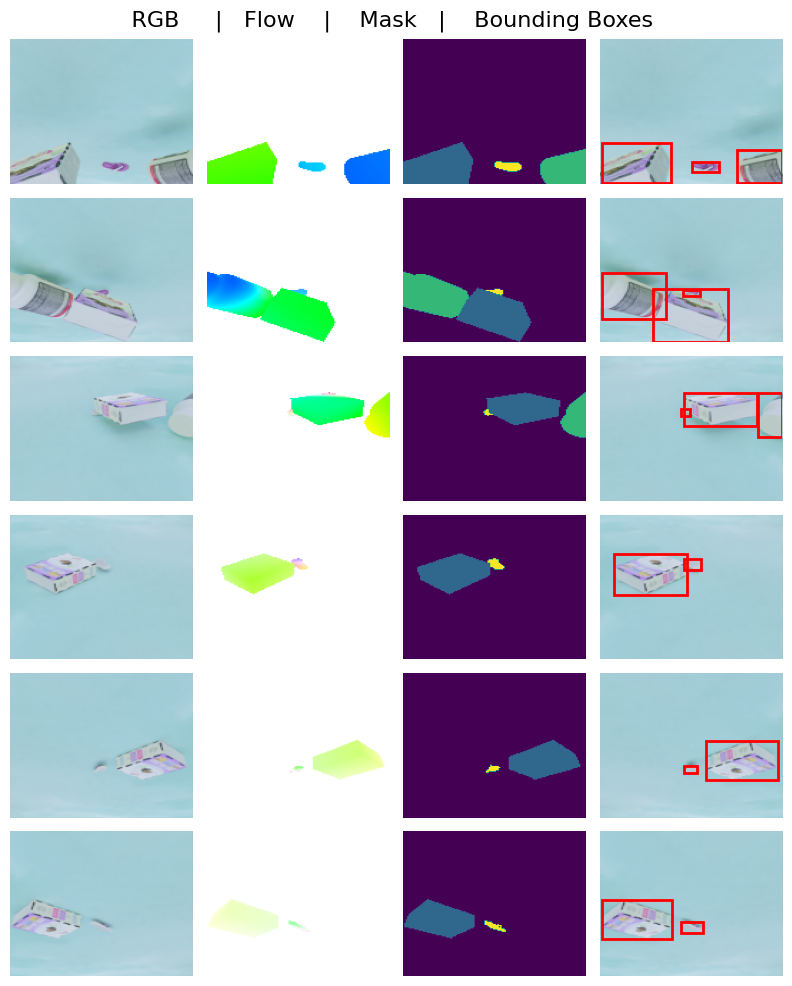

In [10]:
rgbs, masks, flows, coords = next(iter(test_loader))

idx = np.random.randint(0, BATCH_SIZE) #select a random video in the batch

video_frames_data = test_dataset.get_video_frame_labels(coords['com'][idx], 
                                                        coords['bbox'][idx], 
                                                        masks['masks'][idx], 
                                                        rgbs[idx], 
                                                        flows[idx])

# 24 frames x 4 columns (RGB, Flow, Mask, BBox)
fig, axes = plt.subplots(6, 4, figsize=(8, 10))
fig.suptitle('    RGB     |   Flow    |    Mask   |    Bounding Boxes     ', fontsize=16)

i = 0

transformed_data = ParameterCompose([RandomHorizontalFlip(0.7),RandomVerticalFlip(p=0.7)])

for frame_idx in range(1,len(video_frames_data),4):
# for frame_idx in range(len(video_frames_data)):

    coord, bbox, mask, rgb, flow = video_frames_data[frame_idx]
    coord, bbox, mask, rgb, flow=transformed_data((coord, bbox, mask, rgb, flow))
    # RGB image
    axes[i, 0].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 0].axis("off")
    # axes[i, 0].set_title(f"RGB Frame {frame_idx}")
    axes[i, 0].set_aspect('auto')
    
    # Flow image
    axes[i, 1].imshow((flow).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 1].axis("off")
    # axes[i, 1].set_title(f"Flow Frame {frame_idx}")
    axes[i, 1].set_aspect('auto')
    
    
    # Mask image
    axes[i, 2].imshow((mask).clamp(0, 255).byte().numpy())
    axes[i, 2].axis("off")
    # axes[i, 2].set_title(f"Mask Frame {frame_idx}")
    axes[i, 2].set_aspect('auto')
    
    
    # Bounding boxes visualization
    axes[i, 3].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 3].axis("off")
    # axes[i, 3].set_title(f"BBox Frame {frame_idx}")
    axes[i, 3].set_aspect('auto')
    

    # Draw bounding boxes
    for obj_idx in range(bbox.shape[0]):
        x1, y1, x2, y2 = bbox[obj_idx].tolist()
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        axes[i, 3].add_patch(rect)

    i += 1
    
# Remove whitespace between columns and rows
plt.subplots_adjust(wspace=25, hspace=25)
plt.tight_layout(pad=1)
plt.show()


In [36]:
## Verifying the dataloader  
rgbs, masks, flows, coords = next(iter(test_loader))

print(f"RGBs shape: {rgbs.shape}\nFlows shape: {flows.shape}\nMasks shape: {masks['masks'].shape} \nCoords com shape: {coords['com'].shape}\nCoords bbxs shape: {coords['bbox'].shape}")


RGBs shape: torch.Size([64, 24, 3, 128, 128])
Flows shape: torch.Size([64, 24, 3, 128, 128])
Masks shape: torch.Size([64, 24, 128, 128]) 
Coords com shape: torch.Size([64, 24, 11, 2])
Coords bbxs shape: torch.Size([64, 24, 11, 4])


### Patchifier

Patchified Shape: torch.Size([64, 24, 16, 3072])
Number of patches: 16
Patch size: 32


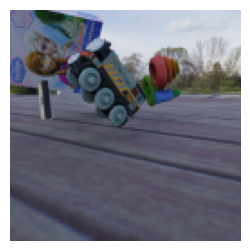

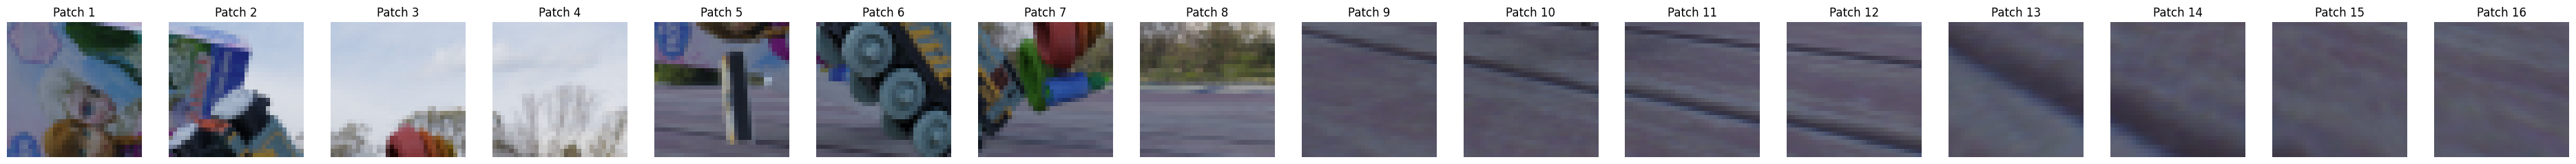

In [12]:
from utils import Patchifier

BATCH_IDX = 4
seq_len = 5
img = rgbs[BATCH_IDX, seq_len]
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0)/255.0)
# print(f"Image Shape: {img.shape}")
plt.axis("off")

patch_size = 32 # num of H and W pixels of each patch
patchifier = Patchifier(patch_size)
patch_data = patchifier(rgbs)
print(f"Patchified Shape: {patch_data.shape}") # (B, seq_len, num_patch_H * num_patch_W, 3 * 32 * 32)

num_patches = patch_data.shape[2] # num_patches = num_patch_H * num_patch_W
print(f"Number of patches: {num_patches}")
patch_size = patchifier.patch_size # patch_size = 16, this the the H,W of each single patch
print(f"Patch size: {patch_size}")
fig, ax = plt.subplots(1, num_patches)
fig.set_size_inches(3 * num_patches, 3)
for i in range(num_patches):
    cur_patch = patch_data[BATCH_IDX, seq_len, i].reshape(3, patch_size, patch_size)
    ax[i].imshow(cur_patch.permute(1, 2, 0)/255.0)
    ax[i].set_title(f"Patch {i+1}")
    ax[i].axis("off")

plt.show()

### Masked Autoencoders

For the first phase of the project, we would be solving the image reconstruction task. For this purpose, we train a transformer based encoder-decoder. For the sake of image reconstruction, we would need to use the masked autoencoder archirecture as in the following image:

# <img src="../docs/146857310-f258c86c-fde6-48e8-9cee-badd2b21bd2c.png" width="640" height="480">



In [ ]:
from encoder import MultiModalVitEncoder

encoder = MultiModalVitEncoder( patch_size = 32, 
                                embed_dim = 128, 
                                attn_dim = 192, 
                                num_heads = 4, 
                                mlp_size = 1024, 
                                encoder_depth = 4, 
                                in_chans = 3, 
                                max_len  = 64,
                                mask_ratio = 0.75,
                                max_objects=11,
                                use_masks=False,
                                use_bboxes=False,
                                norm_pix_loss=False)

In [14]:
encoder

VitEncoder(
  (patch_projection): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=128, bias=True)
  )
  (pos_emb): PositionalEncoding()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (ln_att): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q): Linear(in_features=128, out_features=192, bias=False)
        (k): Linear(in_features=128, out_features=192, bias=False)
        (v): Linear(in_features=128, out_features=192, bias=False)
        (out_proj): Linear(in_features=192, out_features=128, bias=False)
      )
      (ln_mlp): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (mlp): Sequential(
          (0): Linear(in_features=128, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=128, bias=True)
        )
      )
    )
    (1): Transform

In [18]:
x, mask, ids_restore = encoder(rgbs)
print("x shape:", x.shape)
print("mask shape:", mask.shape)
print("ids_restore shape:", ids_restore.shape)

x shape: torch.Size([64, 24, 4, 128])
mask shape: torch.Size([64, 24, 16])
ids_restore shape: torch.Size([64, 24, 16])


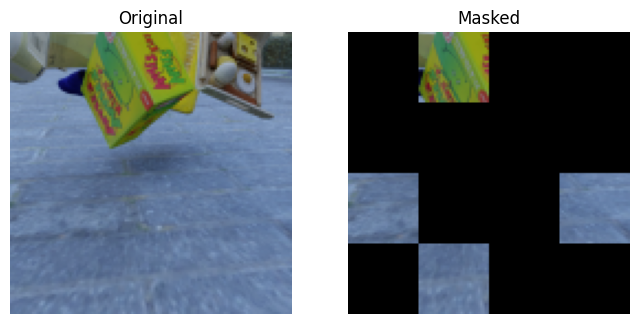

In [19]:
from utils import visualize_masked_image

sample_idx, frame_idx = 2, 0

img = rgbs[sample_idx, frame_idx]     # [3, 128, 128]
mask_frame = mask[sample_idx, frame_idx]  # [N]

visualize_masked_image(img, mask_frame, patch_size=32)


In [ ]:
encoder = MultiModalVitEncoder( patch_size = 32, 
                                embed_dim = 128, 
                                attn_dim = 192, 
                                num_heads = 4, 
                                mlp_size = 1024, 
                                encoder_depth = 4, 
                                in_chans = 3, 
                                max_len  = 64,
                                mask_ratio = 0.75,
                                max_objects=11,
                                use_masks=True,
                                use_bboxes=False,
                                norm_pix_loss=False)

In [48]:

encoded_features, mask, ids_restore = encoder(rgbs, masks)
print("Features shape:\n", encoded_features.shape)
print(f'mask and restored_ids are now dict:', mask.keys())
print("Mask shape:\n images:", mask['image'].shape,f'mask_mask:', mask['mask'].shape)
print("ids_restore shape:\n images:", ids_restore['image'].shape,f'mask:', ids_restore['mask'].shape)

Features shape:
 torch.Size([64, 24, 8, 128])
mask and restored_ids are now dict: dict_keys(['image', 'mask'])
Mask shape:
 images: torch.Size([64, 24, 16]) mask_mask: torch.Size([64, 24, 16])
ids_restore shape:
 images: torch.Size([64, 24, 16]) mask: torch.Size([64, 24, 16])


In [ ]:
encoder = MultiModalVitEncoder( patch_size = 32, 
                                embed_dim = 128, 
                                attn_dim = 192, 
                                num_heads = 4, 
                                mlp_size = 1024, 
                                encoder_depth = 4, 
                                in_chans = 3, 
                                max_len  = 64,
                                mask_ratio = 0.75,
                                max_objects=11,
                                use_masks=True,
                                use_bboxes=True,
                                norm_pix_loss=False)

In [49]:
encoder

VitEncoder(
  (patch_projection): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=128, bias=True)
  )
  (mask_encoder): MaskEncoder(
    (mask_projection): Sequential(
      (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=1024, out_features=128, bias=True)
    )
  )
  (bbox_encoder): BBoxEncoder(
    (bbox_projection): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
    )
    (bbox_final_proj): Linear(in_features=160, out_features=128, bias=True)
  )
  (modality_embeddings): Embedding(3, 128)
  (pos_emb): PositionalEncoding()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (ln_att): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q): Linear(in_features=128, out_features=192, bias=False)
       

In [47]:
encoded_features, mask, ids_restore = encoder(rgbs, masks , coords['bbox'])
print("Features shape:\n", encoded_features.shape)
print(f'mask and restored_ids are now dict:', mask.keys())
print("Mask shape:\n images:", mask['image'].shape,f'mask_mask:', mask['mask'].shape, f'maks bboxs:', mask['bbox'].shape)
print("ids_restore shape:\n images:", ids_restore['image'].shape,f'mask:', ids_restore['mask'].shape, f'bboxs:', ids_restore['bbox'].shape)

Features shape:
 torch.Size([64, 24, 12, 128])
mask and restored_ids are now dict: dict_keys(['image', 'mask', 'bbox'])
Mask shape:
 images: torch.Size([64, 24, 16]) mask_mask: torch.Size([64, 24, 16]) maks bboxs: torch.Size([64, 24, 11])
ids_restore shape:
 images: torch.Size([64, 24, 16]) mask: torch.Size([64, 24, 16]) bboxs: torch.Size([64, 24, 11])
